# Sentiment analysis(NRC Dictionary and Bert)

## NRC Dictionary

In [1]:
# Import dictionary file

import pandas as pd
lexion_df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/NRC-Emotion-Lexicon-v0.92-In105Languages-Nov2017Translations.xlsx')
lexion_df.head()
lexion_df.columns.tolist()
english_df = lexion_df[['English (en)','Positive','Negative','Anger','Anticipation','Disgust','Fear','Joy','Sadness','Surprise','Trust']]
english_df.head()


,English (en),Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,aback,0,0,0,0,0,0,0,0,0,0
1,abacus,0,0,0,0,0,0,0,0,0,1
2,abandon,0,1,0,0,0,1,0,1,0,0
3,abandoned,0,1,1,0,0,1,0,1,0,0
4,abandonment,0,1,1,0,0,1,0,1,1,0


In [2]:
#Create the sentiment dictionary

Positive, Negative, Anger, Anticipation, Disgust, Fear, Joy, Sadness, Surprise, Trust= [[] for i in range(10)]
for idx, row in english_df.iterrows():
    if row['Positive']==1:
        Positive.append(row['English (en)'])
    if row['Negative']==1:
        Negative.append(row['English (en)'])
    if row['Anger']==1:
        Anger.append(row['English (en)'])
    if row['Anticipation']==1:
        Anticipation.append(row['English (en)'])
    if row['Disgust']==1:
        Disgust.append(row['English (en)'])
    if row['Fear']==1:
        Fear.append(row['English (en)'])
    if row['Joy']==1:
        Joy.append(row['English (en)'])
    if row['Sadness']==1:
        Sadness.append(row['English (en)'])
    if row['Surprise']==1:
        Surprise.append(row['English (en)'])
    if row['Trust']==1:
        Trust.append(row['English (en)'])
print('Dictionary done')

Dictionary done


In [3]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag
import re

# Corpus path
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/china_paragraphs.xlsx"
df = pd.read_excel(file_path)

# Get content
china_paragraphs = df['china_paragraph']

# Lemmatizer and stopwords
wordnet_lemmatizer = WordNetLemmatizer()
sr = set(stopwords.words('english')) 

def tokenize(sentence):
    '''
        Remove extra spaces, word segmentation, and part-of-speech tagging
    '''
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = sentence.replace("United", "America").replace("States", "America").replace("American", "America").replace("economic","economy").replace("Chinese","China").replace("freedom","free").replace("viet-nam","vietnam")
    token_words = word_tokenize(sentence)
    token_words = pos_tag(token_words)   
    return token_words

wordnet_lematizer = WordNetLemmatizer()

def stem(token_words):
    '''
        Word form normalization
    '''
    words_lematizer = []
    for word, tag in token_words:
        if tag.startswith('NN'):
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='n')  
        elif tag.startswith('VB'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='v') 
        elif tag.startswith('JJ'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='a')
        elif tag.startswith('R'): 
            word_lematizer =  wordnet_lematizer.lemmatize(word, pos='r')   
        else: 
            word_lematizer =  wordnet_lematizer.lemmatize(word)
        words_lematizer.append(word_lematizer)
    return words_lematizer

sr = set(stopwords.words('english'))
custom_stopwords = {'we','i','I','the','and','q','s','but',"'s",'u','go','say','class=',"_x000d_","/span",'mr.','p','p1','s1','br','must','like','make','think','would','many','great','come','want','deal','good',"n\'t",'let','play',"also",'nbsp',"nafta",'q.','year','one','two','new','take','know','get','give','lot','thing','house','give','need','america','economy','every','help','last','country'}

combined_stopwords = sr.union(custom_stopwords)

def delete_stopwords(token_words):
    '''
        remove stopwords
    '''
    cleaned_words = [word.lower() for word in token_words if word.lower() not in combined_stopwords]
    return cleaned_words

def is_number(s):
    '''
        number or not
    '''
    try:
        float(s)
        return True
    except ValueError:
        pass
 
    try:
        import unicodedata
        unicodedata.numeric(s)
        return True
    except (TypeError, ValueError):
        pass
 
    return False

characters = [' ',',', '.','DBSCAN', ':', ';', '?', '(', ')', '[', ']', '&', '!', '*', '@', '#', '$', '%','-','...','^','{','}', '‘', '’','“','”','<','>','-','--','——',"—","\'\'"]
def delete_characters(token_words):
    '''
        no punctuation and number
    '''
    words_list = [word for word in token_words if word not in characters and not is_number(word)]
    return words_list

def to_lower(token_words):
    '''
        to lower letter
    '''
    words_lists = [x.lower() for x in token_words]
    return words_lists

def pre_process(text):
    '''
        preprocessing
    '''
    token_words = tokenize(text)
    token_words = stem(token_words)
    token_words = delete_stopwords(token_words)
    token_words = delete_characters(token_words)
    token_words = to_lower(token_words)
    return token_words

# main 
if __name__ == '__main__':
    data_set = []  

    for paragraph in china_paragraphs:
        processed_paragraph = pre_process(paragraph)
        if processed_paragraph:  
            data_set.append(processed_paragraph)

    for item in data_set[:5]:  
        print(item)

['decision', 'force', 'nations', 'strive', 'limit', 'conflict', 'possible', 'see', 'conflict', 'korea', 'extend', 'try', 'prevent', 'world', 'war—not', 'start', 'best', 'way', 'plain', 'free', 'continue', 'resist', 'attack', 'may', 'ask', 'ca', 'step', 'punish', 'aggressor', 'bomb', 'manchuria', 'china', 'assist', 'china', 'nationalist', 'troop', 'land', 'mainland', 'china', 'run', 'grave', 'risk', 'start', 'general', 'war', 'happen', 'bring', 'exact', 'situation', 'try', 'prevent', 'become', 'entangled', 'vast', 'conflict', 'continent', 'asia', 'task', 'become', 'immeasurably', 'difficult', 'world', 'suit', 'ambition', 'kremlin', 'military', 'force', 'commit', 'full-scale', 'war', 'red', 'china']
['see', 'conflict', 'korea', 'extend', 'try', 'prevent', 'world', 'war—not', 'start', 'best', 'way', 'plain', 'free', 'continue', 'resist', 'attack', 'may', 'ask', 'ca', 'step', 'punish', 'aggressor', 'bomb', 'manchuria', 'china', 'assist', 'china', 'nationalist', 'troop', 'land', 'mainland',

### Step3: Emotion caculationa and analysis

In [4]:
def emotion_caculate(wordlist):
    positive, negative, anger, anticipation, disgust, fear, joy, sadness, surprise, trust = [0 for i in range(10)]
    wordset = set(wordlist)  
    wordfreq = []
    for word in wordset:
        freq = wordlist.count(word)
        if word in Positive:
            positive+=freq
        if word in Negative:
            negative+=freq
        if word in Anger:
            anger+=freq  
        if word in Anticipation:
            anticipation+=freq
        if word in Disgust:
            disgust+=freq
        if word in Fear:
            fear+=freq
        if word in Joy:
            joy+=freq
        if word in Sadness:
            sadness+=freq
        if word in Surprise:
            surprise+=freq
        if word in Trust:
            trust+=freq
            
    emotion_info = {
        'positive': positive,
        'negative': negative,
        'anger': anger,
        'anticipation': anticipation,
        'disgust': disgust,
        'fear':fear,
        'joy':joy,
        'sadness':sadness,
        'surprise':surprise,
        'trust':trust,
        'length':len(wordlist)
    }
    score_list = list(emotion_info.values())
    return score_list

In [5]:
def emotion_analyse():
    senti_count = []

    for paragraph in data_set:
        score = emotion_caculate(paragraph)  
        senti_count.append(score)  
            
    print(senti_count)
    
    name = ['positive', 'negative', 'anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust', 'length']
    
    result_df = pd.DataFrame(columns=name, data=senti_count)
    result_df.to_excel("/Users/chentangying/Desktop/sem2/ml/proj/nrc_sentiment_result.xlsx", index=False)

emotion_analyse()

[[7, 15, 9, 7, 1, 18, 1, 6, 1, 4, 72], [8, 15, 8, 6, 1, 17, 1, 5, 1, 4, 74], [8, 13, 6, 4, 1, 14, 1, 7, 1, 3, 71], [20, 8, 5, 5, 1, 4, 6, 2, 3, 12, 92], [18, 8, 7, 10, 2, 6, 8, 9, 1, 15, 108], [35, 31, 19, 8, 1, 27, 6, 6, 4, 19, 209], [36, 30, 22, 13, 2, 30, 7, 7, 6, 27, 233], [11, 7, 2, 11, 0, 3, 9, 1, 4, 6, 76], [33, 9, 6, 11, 1, 9, 6, 3, 2, 25, 132], [37, 8, 6, 12, 1, 9, 6, 3, 2, 26, 138], [36, 8, 5, 21, 0, 12, 15, 4, 5, 32, 183], [61, 20, 15, 24, 8, 22, 19, 6, 7, 40, 224], [41, 14, 5, 19, 1, 11, 13, 4, 5, 33, 216], [18, 10, 5, 5, 2, 8, 4, 5, 5, 11, 122], [15, 11, 5, 5, 2, 9, 4, 5, 5, 10, 118], [16, 7, 5, 6, 1, 3, 6, 4, 3, 20, 121], [14, 7, 6, 7, 1, 7, 5, 2, 2, 12, 94], [17, 13, 3, 11, 2, 6, 3, 3, 4, 7, 124], [10, 4, 1, 5, 0, 5, 4, 1, 2, 4, 67], [15, 6, 1, 4, 0, 3, 1, 1, 1, 10, 80], [11, 10, 4, 1, 0, 5, 0, 1, 0, 7, 99], [8, 7, 4, 1, 0, 5, 1, 1, 1, 13, 83], [3, 5, 4, 1, 0, 3, 1, 3, 1, 1, 32], [10, 8, 5, 4, 0, 1, 4, 5, 4, 4, 45], [9, 13, 9, 5, 3, 1, 7, 6, 6, 7, 56], [32, 23, 13, 15, 2

## Analysis and Visualization
### Sentiment-Topic

In [6]:
import pandas as pd

file_path = '/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_result.xlsx'  
df = pd.read_excel(file_path)


df = df.iloc[:, [0, 2, 3]] 

# Topic
df.set_index(df.columns[0], inplace=True)

# Sentiment Score
if 'positive' in df.columns and 'negative' in df.columns:
    df['total'] = df['positive'] - df['negative']

# Total Socre
result = df.groupby(df.index).sum()

result.reset_index(inplace=True)  
result.columns.name = '主题' 
result.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_topic.xlsx', index=False) 

print(result)

主题                                              topic  positive  negative  \
0                                   COVID-19 Response       215       185   
1                                Diplomatic Relations      2011       854   
2                                 Economy Cooperation       702       271   
3                     Education (STEM, Collaboration)        57        20   
4                       National Defense and Military      1439       977   
5   Technological Innovation (AI, 5G, Digital Gove...       162        39   
6                     Trade and Economy (Competition)      1098       586   
7                                             Unknown       389       162   

主题  total  
0      30  
1    1157  
2     431  
3      37  
4     462  
5     123  
6     512  
7     227  


In [7]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_topic.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,positive,negative,total
topic,,,
COVID-19 Response,215,185,30
Diplomatic Relations,2011,854,1157
Economy Cooperation,702,271,431
"Education (STEM, Collaboration)",57,20,37
National Defense and Military,1439,977,462


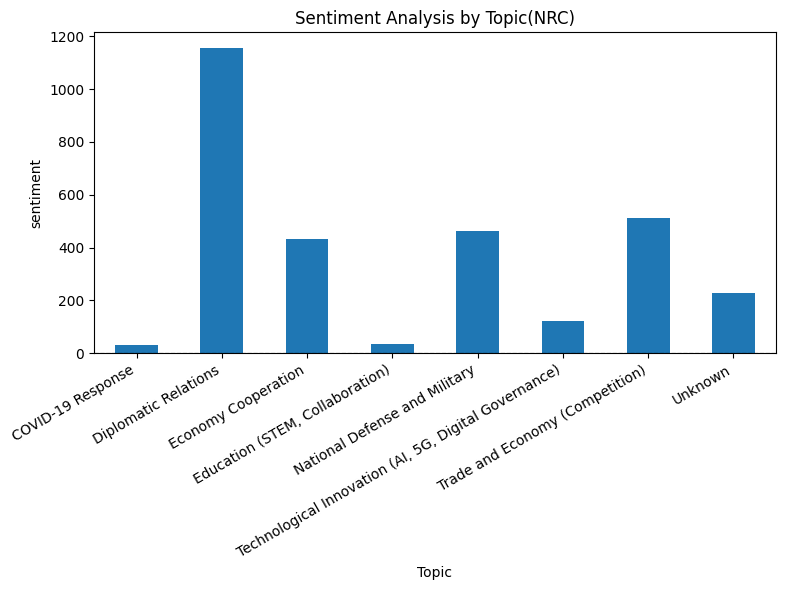

In [8]:
# bar chart
data_total = data[['total']]

ax = data_total.plot(kind='bar', figsize=(8, 6), legend=False)
plt.title('Sentiment Analysis by Topic(NRC)')
plt.xlabel('Topic')
plt.ylabel('sentiment')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

plt.tight_layout()

plt.show()

### Sentiment-Topic average

In [9]:
import pandas as pd

file_path = '/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_result.xlsx'  
df = pd.read_excel(file_path)

# Remove specified columns
columns_to_drop = df.columns[[1, 4, 5, 6, 7, 8, 9, 10, 11, 13]]
df.drop(columns=columns_to_drop, inplace=True)

# Set index to the first column
df.set_index(df.columns[0], inplace=True)

# Sentiment Score
if 'positive' in df.columns and 'negative' in df.columns and 'length' in df.columns:
    df['total'] = (df['positive'] - df['negative'])/df['length']

# Calculate the total sentiment and average sentiment for each topic
result = df.groupby(df.index).agg(total_sentiment=('total', 'sum'), count=('total', 'size'))

# Calculate final average sentiment for each topic
result['average_sentiment'] = result['total_sentiment'] / result['count']

# Reset index and rename columns
result.reset_index(inplace=True)  
result.columns.name = '主题' 

# Save the result to Excel
result.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_topic2.xlsx', index=False) 

print(result)

主题                                              topic  total_sentiment  count  \
0                                   COVID-19 Response         0.213420     24   
1                                Diplomatic Relations        11.968877    113   
2                                 Economy Cooperation         4.684902     41   
3                     Education (STEM, Collaboration)         0.609091      4   
4                       National Defense and Military         4.559637     92   
5   Technological Innovation (AI, 5G, Digital Gove...         1.384297     10   
6                     Trade and Economy (Competition)         7.002035    106   
7                                             Unknown         2.602986     23   

主题  average_sentiment  
0            0.008892  
1            0.105919  
2            0.114266  
3            0.152273  
4            0.049561  
5            0.138430  
6            0.066057  
7            0.113173  


In [10]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_topic2.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,total_sentiment,count,average_sentiment
topic,,,
COVID-19 Response,0.213420,24,0.008892
Diplomatic Relations,11.968877,113,0.105919
Economy Cooperation,4.684902,41,0.114266
"Education (STEM, Collaboration)",0.609091,4,0.152273
National Defense and Military,4.559637,92,0.049561


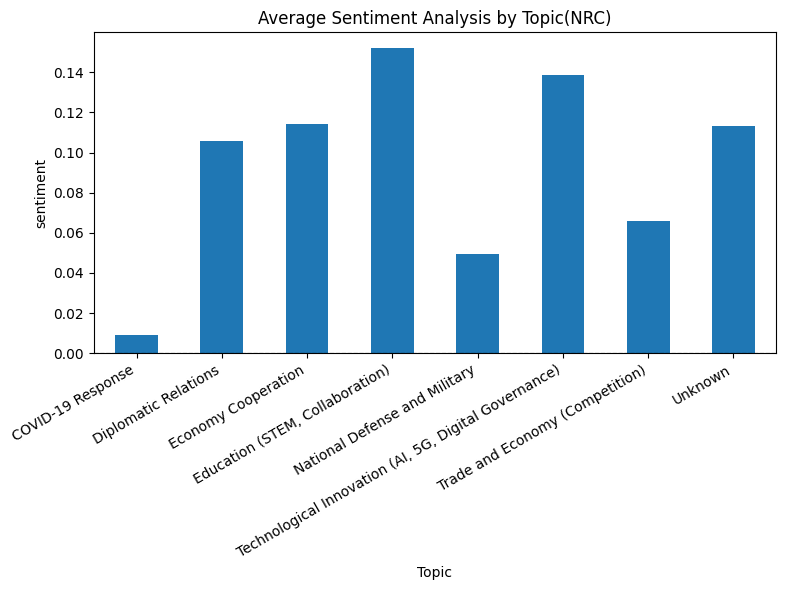

In [11]:
# bar chart
data_total = data['average_sentiment']

ax = data_total.plot(kind='bar', figsize=(8, 6), legend=False)
plt.title('Average Sentiment Analysis by Topic(NRC)')
plt.xlabel('Topic')
plt.ylabel('sentiment')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

plt.tight_layout()

plt.show()

### Sentiment- President

In [12]:
import pandas as pd

file_path = '/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_result.xlsx'  
df = pd.read_excel(file_path)


df = df.iloc[:, [1, 2, 3]] 

# President
df.set_index(df.columns[0], inplace=True)

# Total Socre
result = df.groupby(df.index).sum()

result.reset_index(inplace=True)  
result.columns.name = 'President' 
result.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_president.xlsx', index=False) 

print(result)

President             president  positive  negative
0                  Barack Obama       494       215
1                  Bill Clinton       335       112
2                  Donald Trump      1447       925
3          Dwight D. Eisenhower       308       135
4             George H. W. Bush        80        42
5                George W. Bush       209        88
6                   Gerald Ford       381       110
7               Harry S. Truman        43        51
8                  Jimmy Carter       458       148
9                     Joe Biden       492       245
10              John F. Kennedy       360       227
11            Lyndon B. Johnson       930       573
12             Richard M. Nixon       267       136
13                Ronald Reagan       269        87


In [13]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_president.xlsx"

# 读取 Excel 文件
data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,positive,negative
president,,
Barack Obama,494,215
Bill Clinton,335,112
Donald Trump,1447,925
Dwight D. Eisenhower,308,135
George H. W. Bush,80,42


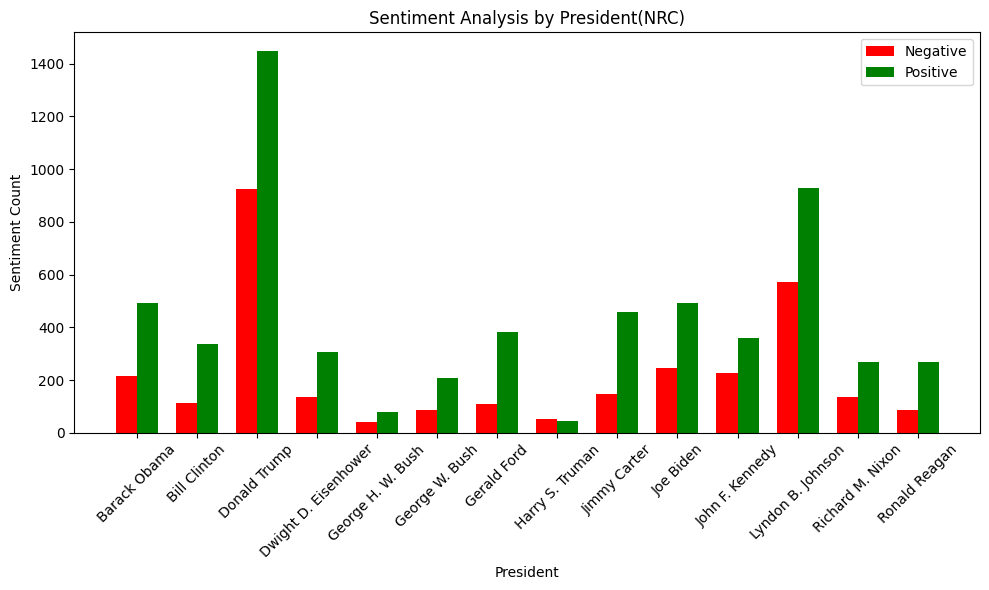

In [14]:
import numpy as np

bar_width = 0.35
x = np.arange(len(data.index))

# bar
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width / 2, data['negative'], width=bar_width, label='Negative', color='red')
ax.bar(x + bar_width / 2, data['positive'], width=bar_width, label='Positive', color='green')

ax.set_title('Sentiment Analysis by President(NRC)')
ax.set_xlabel('President')
ax.set_ylabel('Sentiment Count')
ax.set_xticks(x)
ax.set_xticklabels(data.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Sentiment-President average

In [15]:
import pandas as pd

file_path = '/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_result.xlsx'  
df = pd.read_excel(file_path)

# Remove specified columns
columns_to_drop = df.columns[[0, 4, 5, 6, 7, 8, 9, 10, 11, 13]]
df.drop(columns=columns_to_drop, inplace=True)

# Set index to the first column
df.set_index(df.columns[0], inplace=True)

# Calculate normalized positive and negative scores
if 'positive' in df.columns and 'negative' in df.columns and 'length' in df.columns:
    df['pos'] = df['positive'] / df['length']
    df['neg'] = df['negative'] / df['length']

# Calculate total positive and negative sentiment for each topic
result = df.groupby(df.index).agg(
    total_positive=('pos', 'sum'),
    total_negative=('neg', 'sum'),
    count=('pos', 'size')
)

# Calculate average sentiment for each topic
result['average_positive'] = result['total_positive'] / result['count']
result['average_negative'] = result['total_negative'] / result['count']

# Reset index and rename columns
result.reset_index(inplace=True)  
result.columns.name = '主题' 

# Save the result to Excel
result.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_president2.xlsx', index=False) 

print(result)

主题             president  total_positive  total_negative  count  \
0           Barack Obama        6.009033        2.633569     35   
1           Bill Clinton        3.348819        1.135242     18   
2           Donald Trump       22.729390       14.995800    152   
3   Dwight D. Eisenhower        1.810348        0.767229      9   
4      George H. W. Bush        0.820421        0.395386      5   
5         George W. Bush        2.334868        0.915790     12   
6            Gerald Ford        4.032388        1.102092     17   
7        Harry S. Truman        0.535398        0.681091      4   
8           Jimmy Carter        4.793567        1.507746     23   
9              Joe Biden        5.587779        2.525967     32   
10       John F. Kennedy        3.334582        2.203741     20   
11     Lyndon B. Johnson       10.365183        6.923573     58   
12      Richard M. Nixon        2.265805        1.279049     13   
13         Ronald Reagan        2.921479        0.797540     1

In [16]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/nrc_sentiment_president2.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,total_positive,total_negative,count,average_positive,average_negative
president,,,,,
Barack Obama,6.009033,2.633569,35,0.171687,0.075245
Bill Clinton,3.348819,1.135242,18,0.186045,0.063069
Donald Trump,22.729390,14.995800,152,0.149535,0.098657
Dwight D. Eisenhower,1.810348,0.767229,9,0.201150,0.085248
George H. W. Bush,0.820421,0.395386,5,0.164084,0.079077


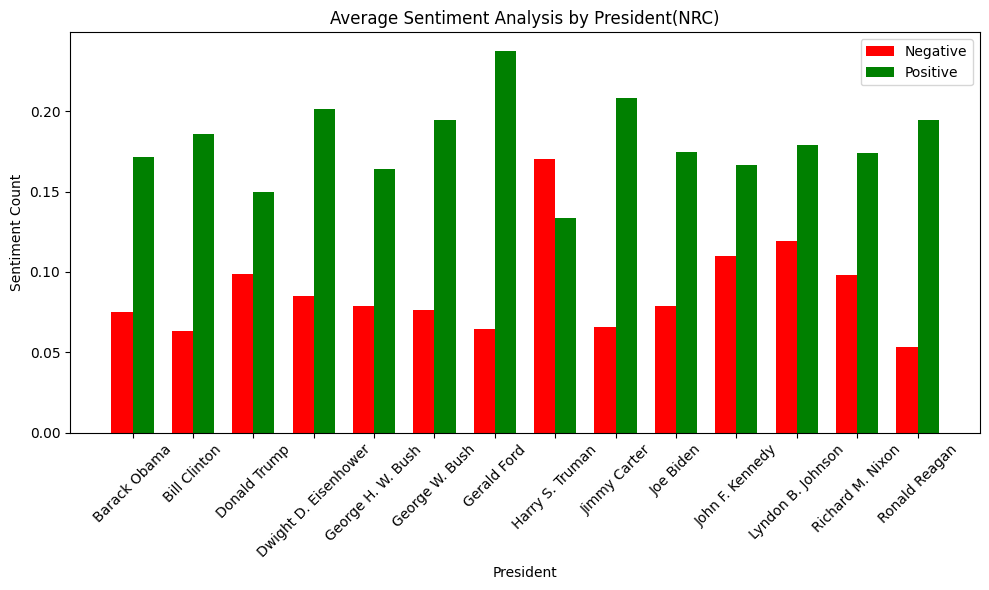

In [17]:
import numpy as np

bar_width = 0.35
x = np.arange(len(data.index))

#bar
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width / 2, data['average_negative'], width=bar_width, label='Negative', color='red')
ax.bar(x + bar_width / 2, data['average_positive'], width=bar_width, label='Positive', color='green')

ax.set_title('Average Sentiment Analysis by President(NRC)')
ax.set_xlabel('President')
ax.set_ylabel('Sentiment Count')
ax.set_xticks(x)
ax.set_xticklabels(data.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## Bert Sentiment  Analysis and Visualization

In [18]:
import pandas as pd
import re
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk import word_tokenize, pos_tag

file_path = "/Users/chentangying/Desktop/sem2/ml/proj/china_paragraphs.xlsx"
df = pd.read_excel(file_path)
china_paragraphs = df['china_paragraph']
wordnet_lemmatizer = WordNetLemmatizer()
sr = set(stopwords.words('english'))

# imort pre-training model
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# data cleaning
def tokenize(sentence):
    sentence = re.sub(r'\s+', ' ', sentence)
    token_words = word_tokenize(sentence)
    token_words = pos_tag(token_words)   
    return token_words

def stem(token_words):
    words_lematizer = []
    for word, tag in token_words:
        if tag.startswith('NN'):
            word_lematizer = wordnet_lemmatizer.lemmatize(word, pos='n')
        elif tag.startswith('VB'):
            word_lematizer = wordnet_lemmatizer.lemmatize(word, pos='v')
        elif tag.startswith('JJ'):
            word_lematizer = wordnet_lemmatizer.lemmatize(word, pos='a') 
        elif tag.startswith('R'):
            word_lematizer = wordnet_lemmatizer.lemmatize(word, pos='r')  
        else:
            word_lematizer = wordnet_lemmatizer.lemmatize(word)
        words_lematizer.append(word_lematizer)
    return words_lematizer

def delete_stopwords(token_words):
    cleaned_words = [word.lower() for word in token_words if word.lower() not in sr]
    return cleaned_words

def pre_process(text):
    token_words = tokenize(text)
    token_words = stem(token_words)
    token_words = delete_stopwords(token_words)
    return token_words

# main
if __name__ == '__main__':
    sentiments = [] 
    for paragraph in china_paragraphs:
        processed_paragraph = pre_process(paragraph)
        
        # sentiment analysis by bert
        inputs = tokenizer(paragraph, return_tensors="pt", truncation=True, padding=True, max_length=512)
        with torch.no_grad():
            outputs = model(**inputs)
        sentiment = torch.argmax(outputs.logits, axis=1).item()
        
        if sentiment == 0:
            sentiments.append("Negative sentiment")
        else:
            sentiments.append("Positive sentiment")

    df['sentiment'] = sentiments
    df.to_excel('bert_sentiment_results.xlsx', index=False)  

### Sentiment-Topic

In [22]:
df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_results.xlsx')  # 替换为您的Excel文件名

df = df.iloc[:, [0, 7]] 

# count by topic
sentiment_counts = df.groupby('topic')['sentiment'].value_counts().unstack(fill_value=0)

# sentiment score
sentiment_counts['sentiment'] = sentiment_counts.get('Positive sentiment', 0) - sentiment_counts.get('Negative sentiment', 0)

sentiment_counts.reset_index(inplace=True)
sentiment_counts.to_excel('bert_sentiment_topic.xlsx', index=False)  # 保存结果到新文件

In [23]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_topic.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,Negative sentiment,Positive sentiment,sentiment
topic,,,
COVID-19 Response,10,14,4
Diplomatic Relations,14,99,85
Economy Cooperation,7,34,27
"Education (STEM, Collaboration)",0,4,4
National Defense and Military,25,67,42


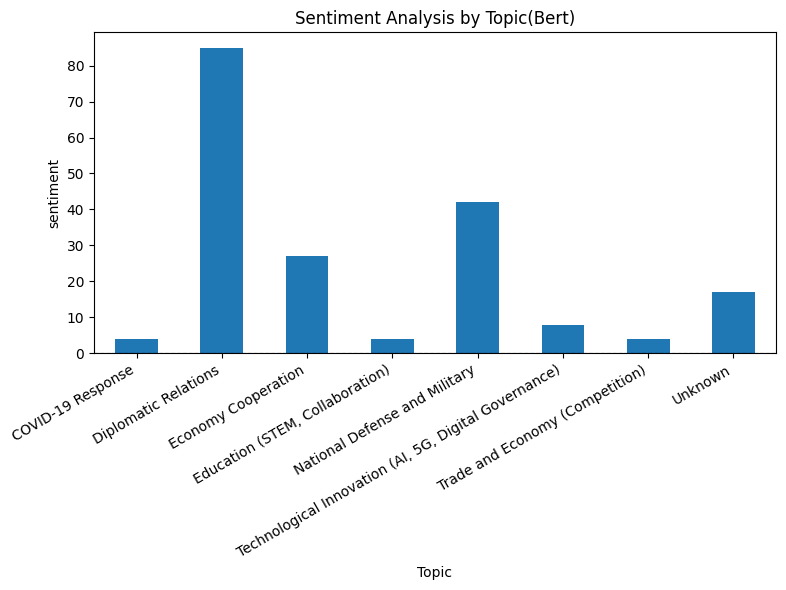

In [24]:
# bar chart
data_total = data[['sentiment']]

ax = data_total.plot(kind='bar', figsize=(8, 6), legend=False)
plt.title('Sentiment Analysis by Topic(Bert)')
plt.xlabel('Topic')
plt.ylabel('sentiment')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

plt.tight_layout()

plt.show()

In [26]:
import pandas as pd

df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_results.xlsx')

df = df.iloc[:, [0, 7]]  # 假设第一列是主题，第二列是情感

# posi & nega
sentiment_counts = df.groupby('topic')['sentiment'].value_counts().unstack(fill_value=0)

# score
sentiment_counts['sentiment'] = sentiment_counts.get('Positive sentiment', 0) - sentiment_counts.get('Negative sentiment', 0)

# count
sentiment_counts['count'] = sentiment_counts['Positive sentiment'] + sentiment_counts['Negative sentiment']

# average
sentiment_counts['average_sentiment'] = sentiment_counts['sentiment'] / sentiment_counts['count']

sentiment_counts.reset_index(inplace=True)
sentiment_counts.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_topic2.xlsx', index=False)  # 保存结果到新文件

print(sentiment_counts)

sentiment                                              topic  \
0                                          COVID-19 Response   
1                                       Diplomatic Relations   
2                                        Economy Cooperation   
3                            Education (STEM, Collaboration)   
4                              National Defense and Military   
5          Technological Innovation (AI, 5G, Digital Gove...   
6                            Trade and Economy (Competition)   
7                                                    Unknown   

sentiment  Negative sentiment  Positive sentiment  sentiment  count  \
0                          10                  14          4     24   
1                          14                  99         85    113   
2                           7                  34         27     41   
3                           0                   4          4      4   
4                          25                  67         42     92 

In [27]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_topic2.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,Negative sentiment,Positive sentiment,sentiment,count,average_sentiment
topic,,,,,
COVID-19 Response,10,14,4,24,0.166667
Diplomatic Relations,14,99,85,113,0.752212
Economy Cooperation,7,34,27,41,0.658537
"Education (STEM, Collaboration)",0,4,4,4,1.000000
National Defense and Military,25,67,42,92,0.456522


Columns in the DataFrame after calculation: ['Negative sentiment', 'Positive sentiment', 'sentiment', 'count', 'average_sentiment']


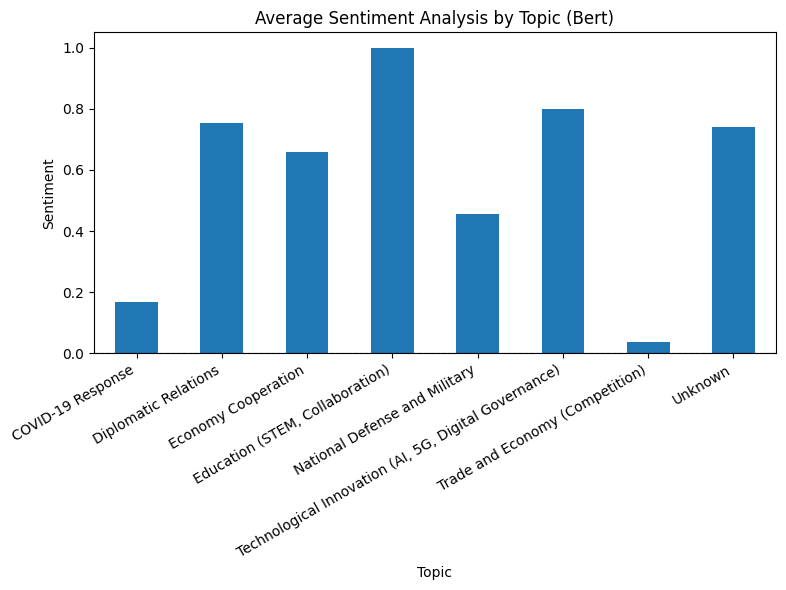

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

data['sentiment'] = data['Positive sentiment'] - data['Negative sentiment']
data['count'] = data['Positive sentiment'] + data['Negative sentiment']

data['average_sentiment'] = data['sentiment'] / data['count']

print("Columns in the DataFrame after calculation:", data.columns.tolist())

if 'average_sentiment' in data.columns:
    data_total = data[['average_sentiment']]

    ax = data_total.plot(kind='bar', figsize=(8, 6), legend=False)
    plt.title('Average Sentiment Analysis by Topic (Bert)')
    plt.xlabel('Topic')
    plt.ylabel('Sentiment')
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Error: 'average_sentiment' column not found in the DataFrame.")

### Sentiment-President

In [42]:
df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_results.xlsx')  # 替换为您的Excel文件名

df = df.iloc[:, [4,7]] 

# count by topic
sentiment_counts = df.groupby('president')['sentiment'].value_counts().unstack(fill_value=0)

# sentiment score
sentiment_counts['sentiment'] = sentiment_counts.get('Positive sentiment', 0) - sentiment_counts.get('Negative sentiment', 0)

sentiment_counts.reset_index(inplace=True)
sentiment_counts.to_excel('bert_sentiment_president.xlsx', index=False)  # 保存结果到新文件

In [44]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_president.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,Negative sentiment,Positive sentiment,sentiment
president,,,
Barack Obama,10,25,15
Bill Clinton,0,18,18
Donald Trump,72,80,8
Dwight D. Eisenhower,0,9,9
George H. W. Bush,1,4,3


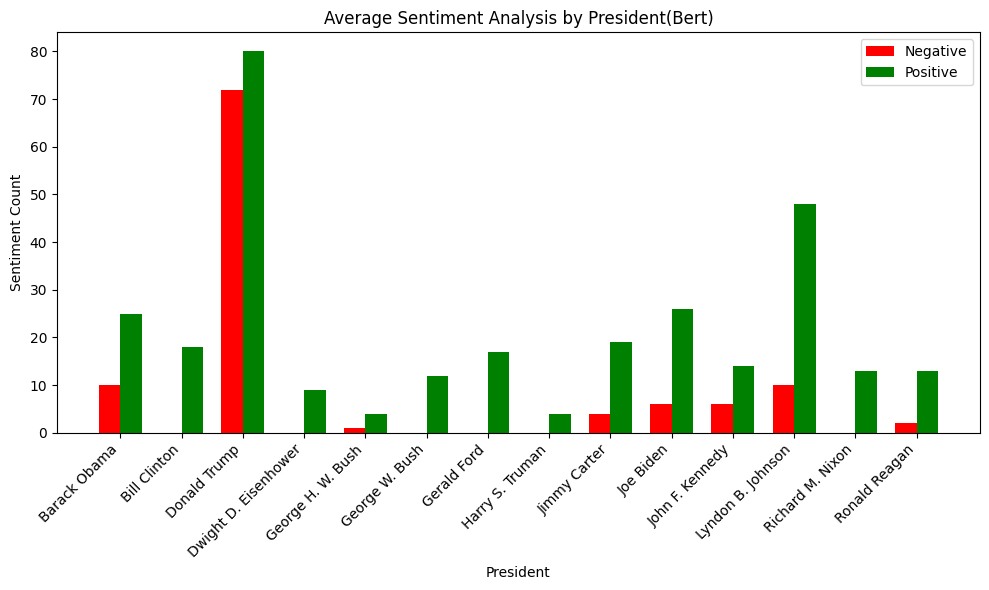

In [45]:
bar_width = 0.35
x = np.arange(len(data.index))

# bar
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width / 2, data['Negative sentiment'], width=bar_width, label='Negative', color='red')
ax.bar(x + bar_width / 2, data['Positive sentiment'], width=bar_width, label='Positive', color='green')

ax.set_title('Average Sentiment Analysis by President(Bert)')
ax.set_xlabel('President')
ax.set_ylabel('Sentiment Count')
ax.set_xticks(x)
ax.set_xticklabels(data.index, rotation=45, ha='right')  # 更改 'ha' 参数为 'right' 以左移标签
ax.legend()

plt.tight_layout()
plt.show()

In [46]:
import pandas as pd

df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_results.xlsx')  

df = df.iloc[:, [4, 7]]  

sentiment_counts = df.groupby('president')['sentiment'].value_counts().unstack(fill_value=0)

# score
sentiment_counts['sentiment'] = sentiment_counts.get('Positive sentiment', 0) - sentiment_counts.get('Negative sentiment', 0)

# count
sentiment_counts['count'] = sentiment_counts['Positive sentiment'] + sentiment_counts['Negative sentiment']

# average
sentiment_counts['average_positive'] = sentiment_counts['Positive sentiment'] / sentiment_counts['Positive sentiment'].sum()
sentiment_counts['average_negative'] = sentiment_counts['Negative sentiment'] / sentiment_counts['Negative sentiment'].sum()

sentiment_counts.reset_index(inplace=True)
sentiment_counts.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_president2.xlsx', index=False)  # 保存结果到新文件

print(sentiment_counts)

sentiment             president  Negative sentiment  Positive sentiment  \
0                  Barack Obama                  10                  25   
1                  Bill Clinton                   0                  18   
2                  Donald Trump                  72                  80   
3          Dwight D. Eisenhower                   0                   9   
4             George H. W. Bush                   1                   4   
5                George W. Bush                   0                  12   
6                   Gerald Ford                   0                  17   
7               Harry S. Truman                   0                   4   
8                  Jimmy Carter                   4                  19   
9                     Joe Biden                   6                  26   
10              John F. Kennedy                   6                  14   
11            Lyndon B. Johnson                  10                  48   
12             Richard M.

In [35]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_president2.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,Negative sentiment,Positive sentiment,sentiment,count,average_positive,average_negative
president,,,,,,
Barack Obama,10,25,15,35,0.082781,0.090090
Bill Clinton,0,18,18,18,0.059603,0.000000
Donald Trump,72,80,8,152,0.264901,0.648649
Dwight D. Eisenhower,0,9,9,9,0.029801,0.000000
George H. W. Bush,1,4,3,5,0.013245,0.009009


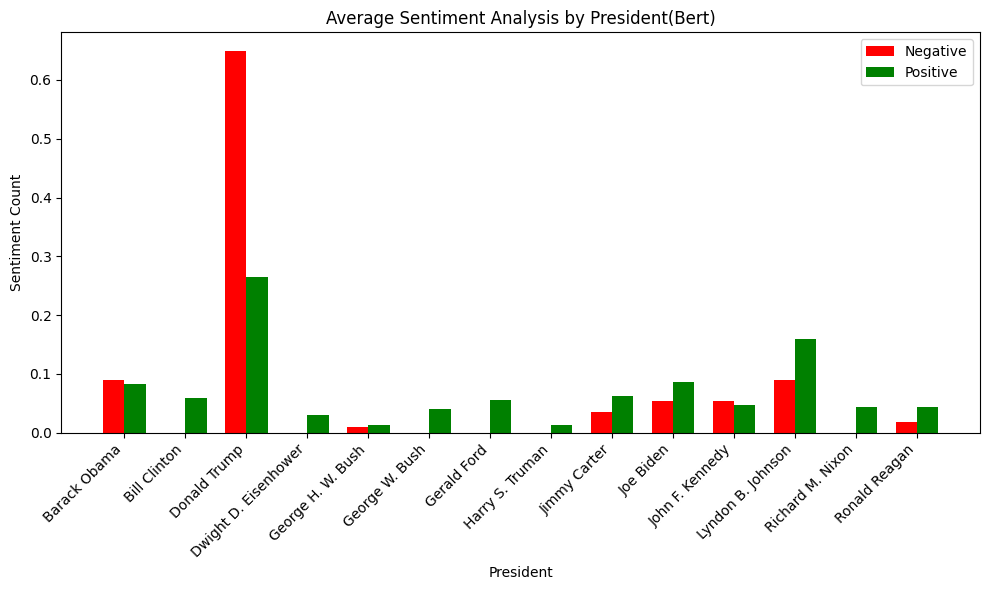

In [36]:
bar_width = 0.35
x = np.arange(len(data.index))

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - bar_width / 2, data['average_negative'], width=bar_width, label='Negative', color='red')
ax.bar(x + bar_width / 2, data['average_positive'], width=bar_width, label='Positive', color='green')

ax.set_title('Average Sentiment Analysis by President(Bert)')
ax.set_xlabel('President')
ax.set_ylabel('Sentiment Count')
ax.set_xticks(x)
ax.set_xticklabels(data.index, rotation=45, ha='right')  # 更改 'ha' 参数为 'right' 以左移标签
ax.legend()

plt.tight_layout()
plt.show()

### Sentiment-Date

In [39]:
import pandas as pd

df = pd.read_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_results.xlsx')

df = df.iloc[:, [2, 7]]  

sentiment_counts = df.groupby('date')['sentiment'].value_counts().unstack(fill_value=0)

# score
sentiment_counts['sentiment'] = sentiment_counts.get('Positive sentiment', 0) - sentiment_counts.get('Negative sentiment', 0)


sentiment_counts.reset_index(inplace=True)
sentiment_counts.to_excel('/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_date.xlsx', index=False)  # 保存结果到新文件

print(sentiment_counts)

sentiment                       date  Negative sentiment  Positive sentiment  \
0                         1951-04-11                   0                   3   
1                         1952-10-22                   0                   1   
2                         1953-01-20                   0                   1   
3                         1953-02-02                   0                   2   
4                         1953-04-16                   0                   1   
..                               ...                 ...                 ...   
144        2024-07-24T20:00:00-04:00                   0                   1   
145        2024-09-24T10:12:00-04:00                   0                   3   
146        2025-01-15T20:00:00-05:00                   0                   2   
147        2025-01-20T12:10:00-05:00                   2                   0   
148        2025-03-04T21:15:00-05:00                   5                   0   

sentiment  sentiment  
0               

In [40]:
import matplotlib.pyplot as plt
file_path = "/Users/chentangying/Desktop/sem2/ml/proj/sentiment/bert_sentiment_date.xlsx"

data = pd.read_excel(file_path)
data.set_index(data.columns[0], inplace=True) 
data = data.apply(pd.to_numeric, errors='coerce')  
data.head()

,Negative sentiment,Positive sentiment,sentiment
date,,,
1951-04-11,0,3,3
1952-10-22,0,1,1
1953-01-20,0,1,1
1953-02-02,0,2,2
1953-04-16,0,1,1


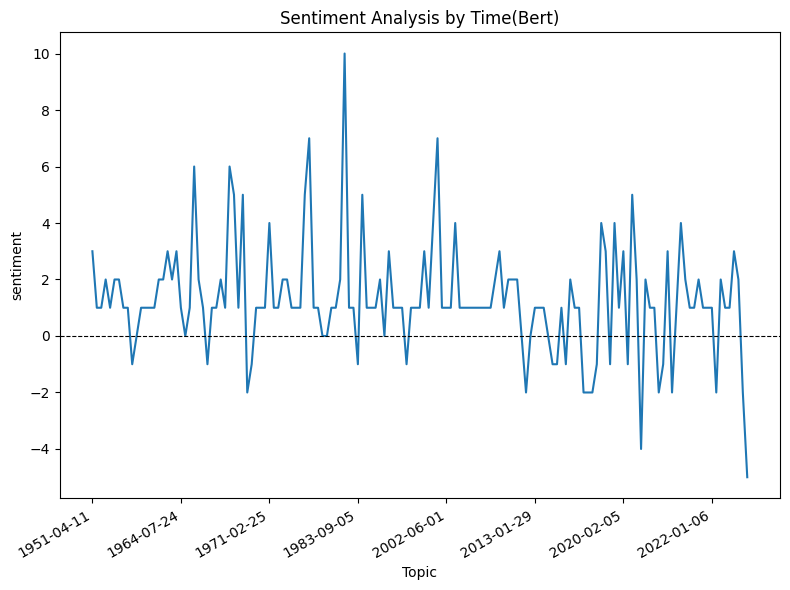

In [41]:
# line chart
data_total = data[['sentiment']]

ax = data_total.plot(kind='line', figsize=(8, 6), legend=False)
plt.title('Sentiment Analysis by Time(Bert)')
plt.xlabel('Topic')
plt.ylabel('sentiment')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)

plt.tight_layout()

plt.show()